In [1]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:892: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


# Define Module 

In [2]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4



# Prepare for simulation

In [ ]:
# Use ModuleProperties to create module variables for our CRNs

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)


# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 400.0

burn_in_time = 100.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]

rates = 0.1* np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])



initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

# Create simulation module variables

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



# Plot species population trajectories over time

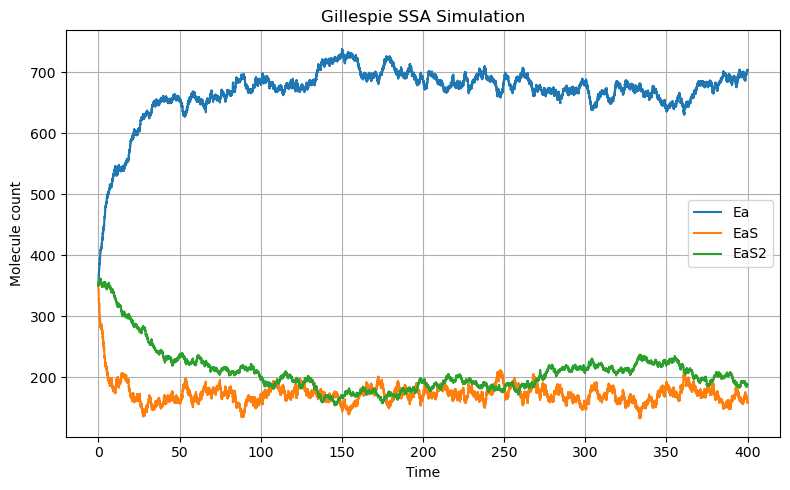

In [4]:
# 1) Change store_trajectories = False (default = True) to skip trajectory plotting. This offers up to 100x speed up.
#
# 2) Add an explicit set of starting populations as a list (in same order as 'species_names' used in ModuleProperties),
#    default is to use pre-defined list 'initial_counts' in RunSSA.

SIM1.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

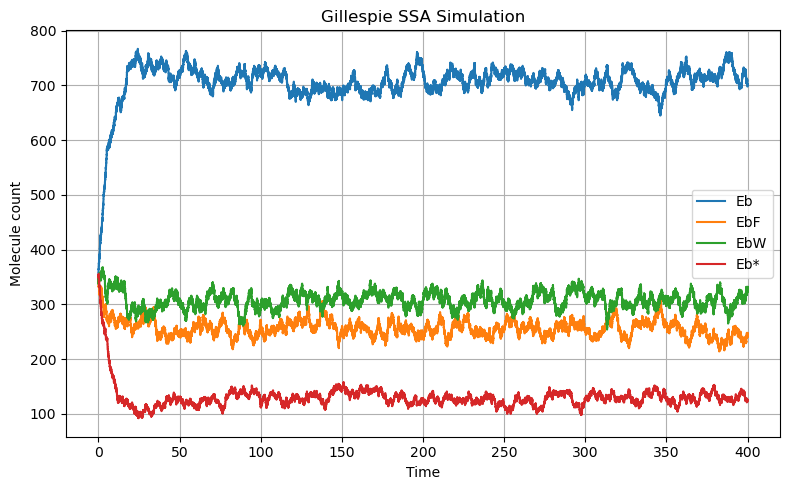

In [9]:
SIM2.run_SSA_and_plot_counts(True)

# Plot the distribution of currents and forces over a set number of iterations 

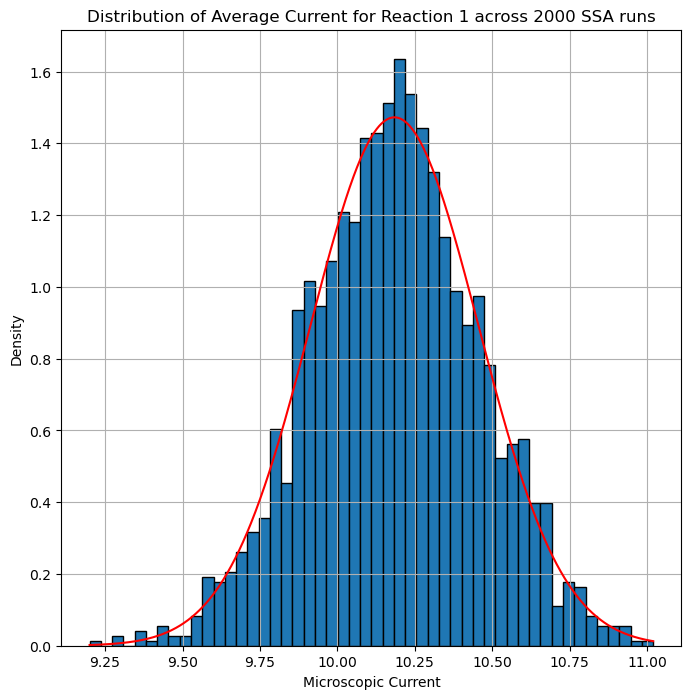

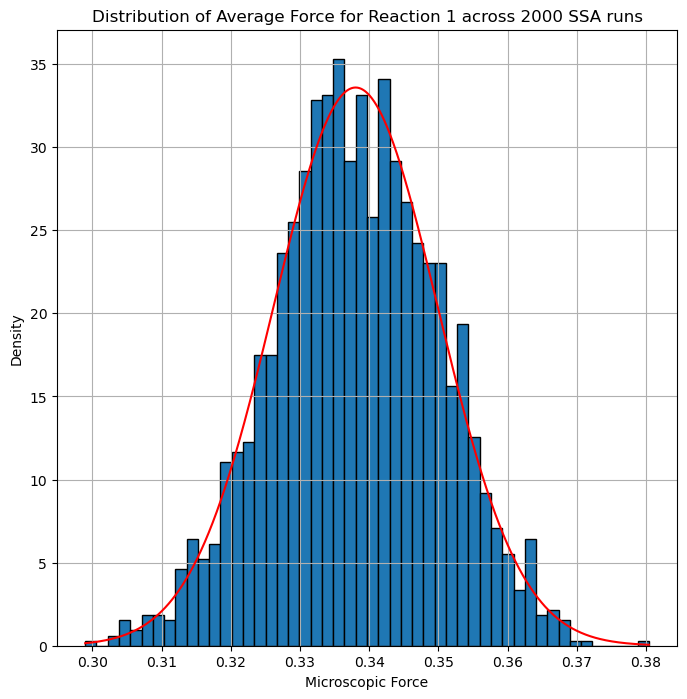

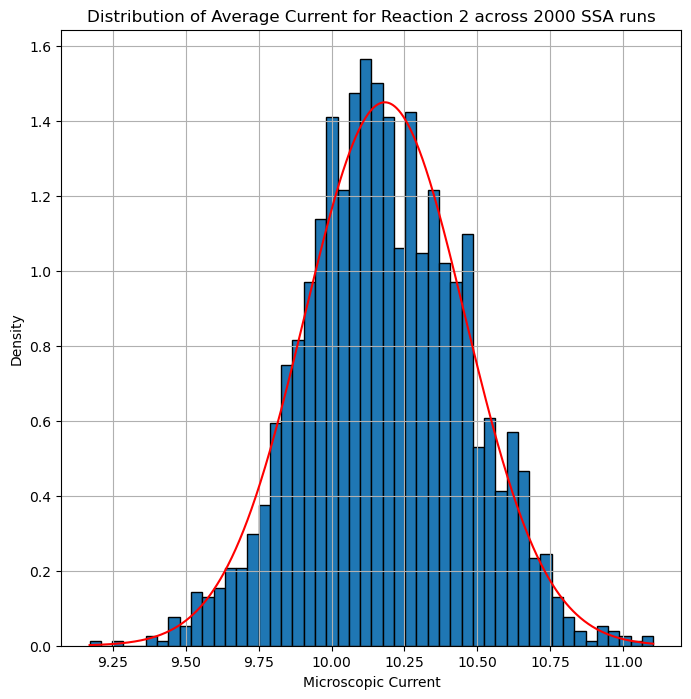

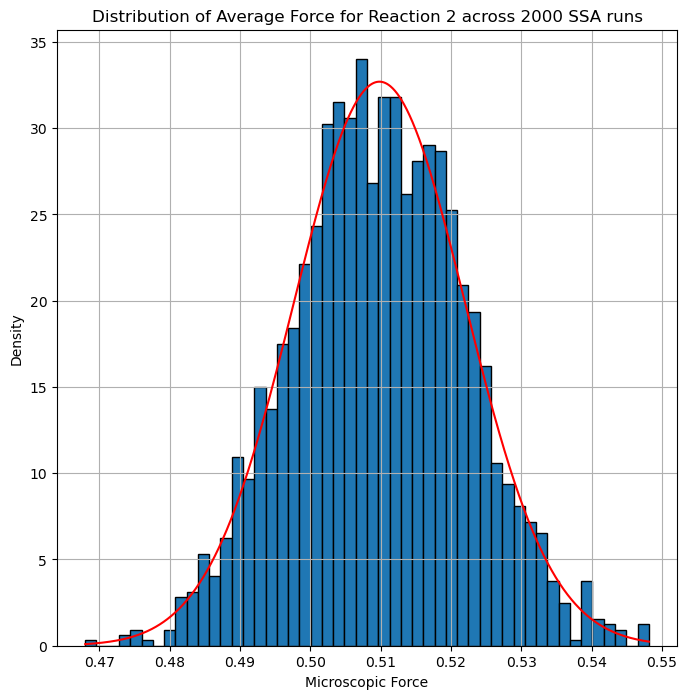

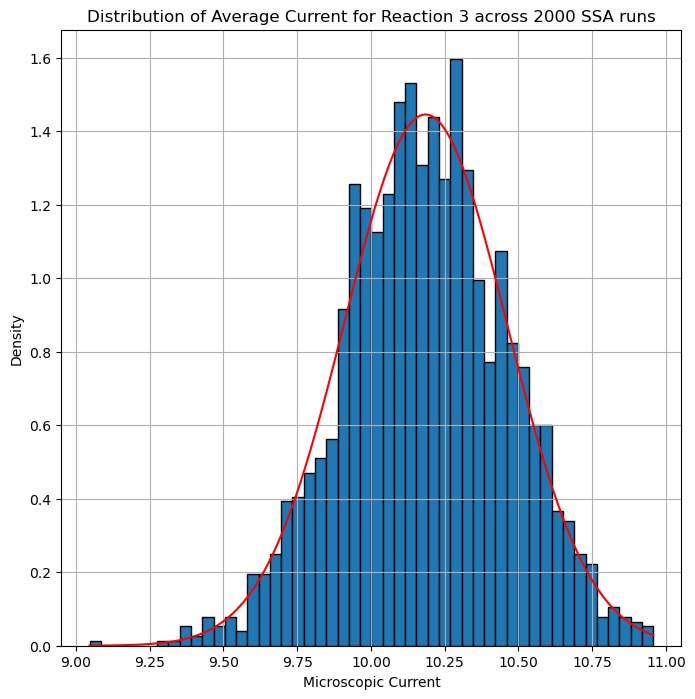

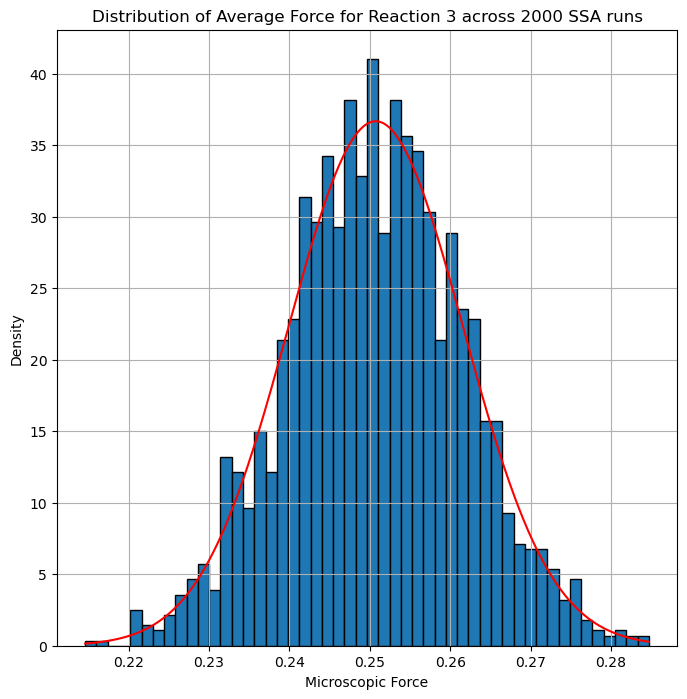

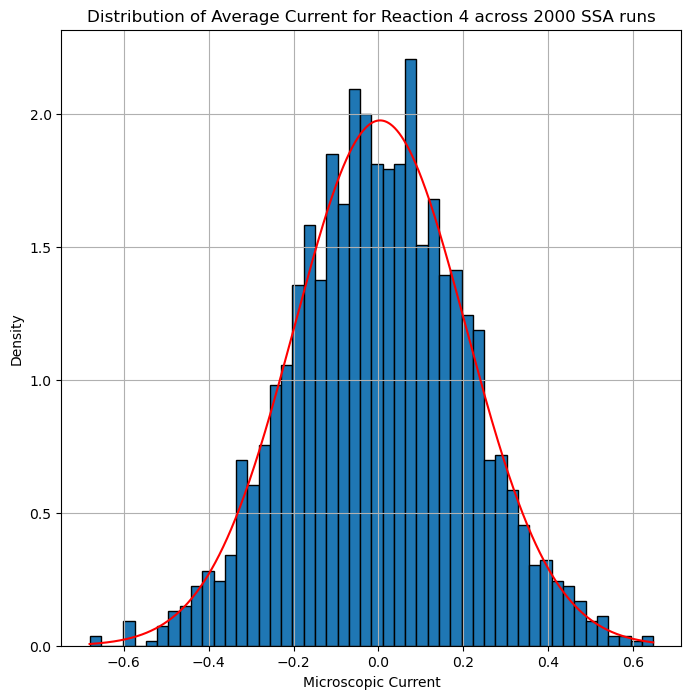

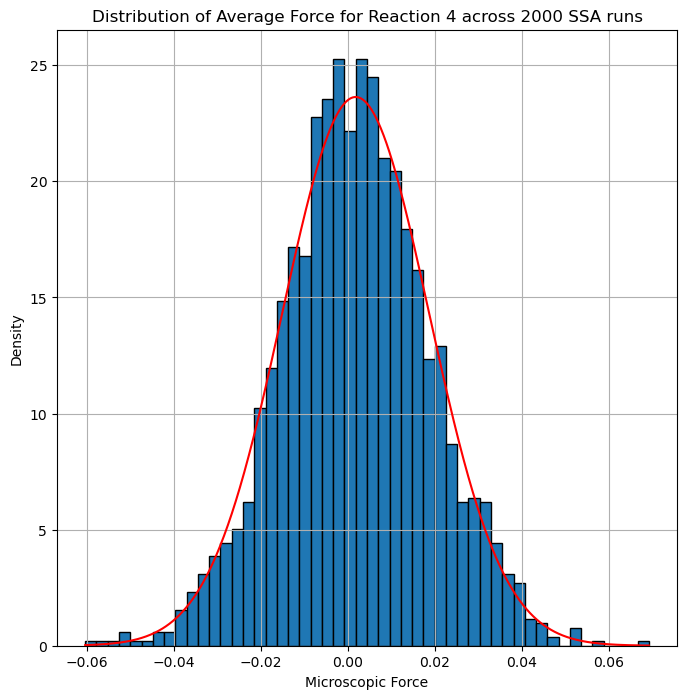

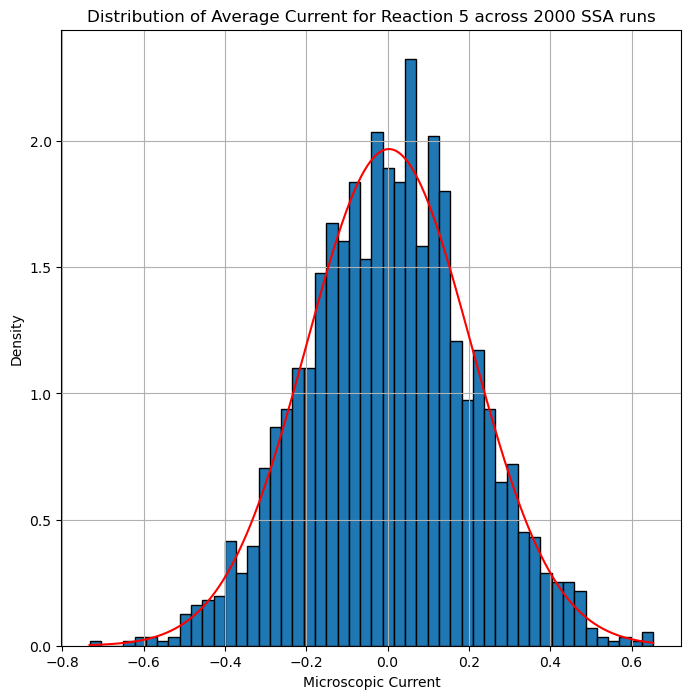

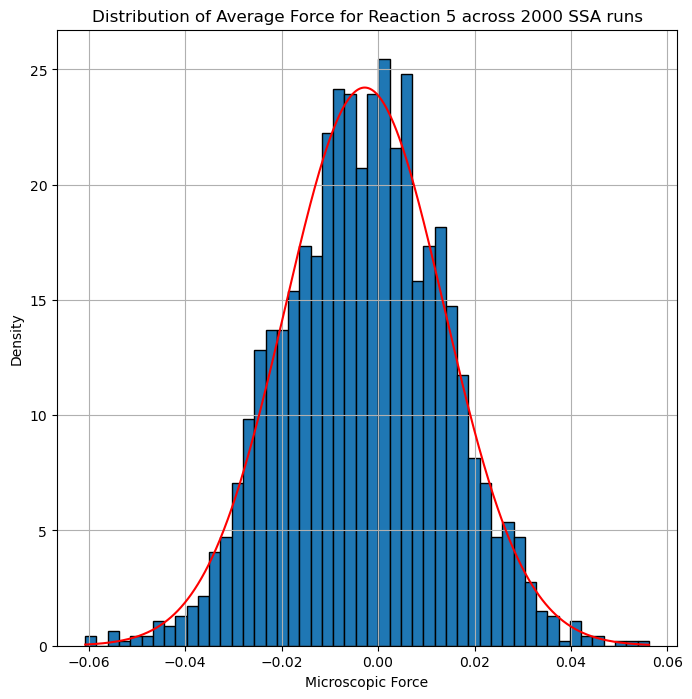

In [ ]:
# This attribute allows us to see how well the currents and forces converge to a Gaussian for a different number of SSA repeats. The plotted data is time averaged current and force across all
# the reactions in the CRN after each individual run of SSA (out of num_iterations). This is helpful for determining how many iterations we should run
# when we want to average these values. The default values are bins=50, num_iterations = 50, Gaussian_points = 1000. Reactions are in order of the columns of the inputted stoichiometric matrix.

SIM1.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)


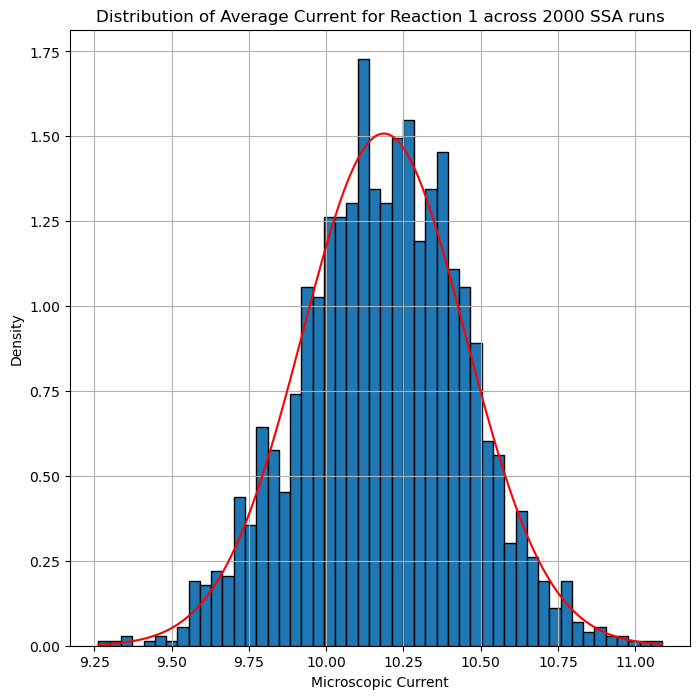

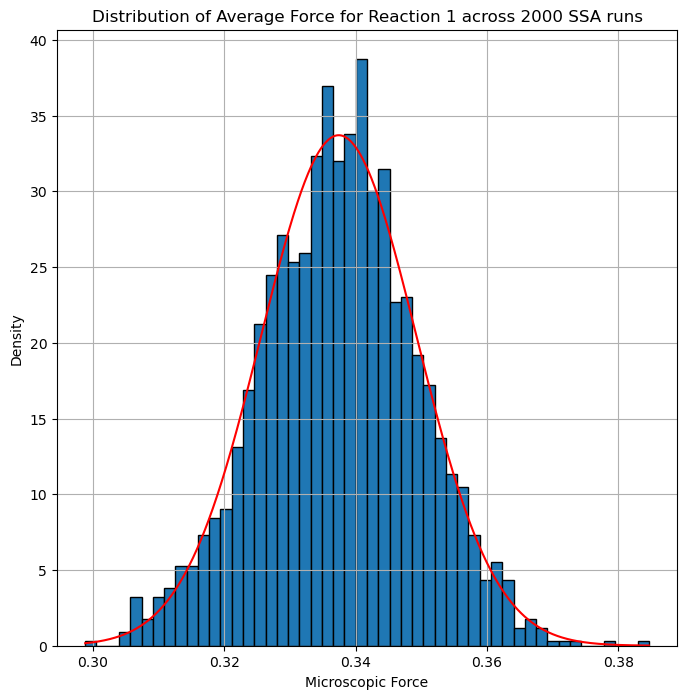

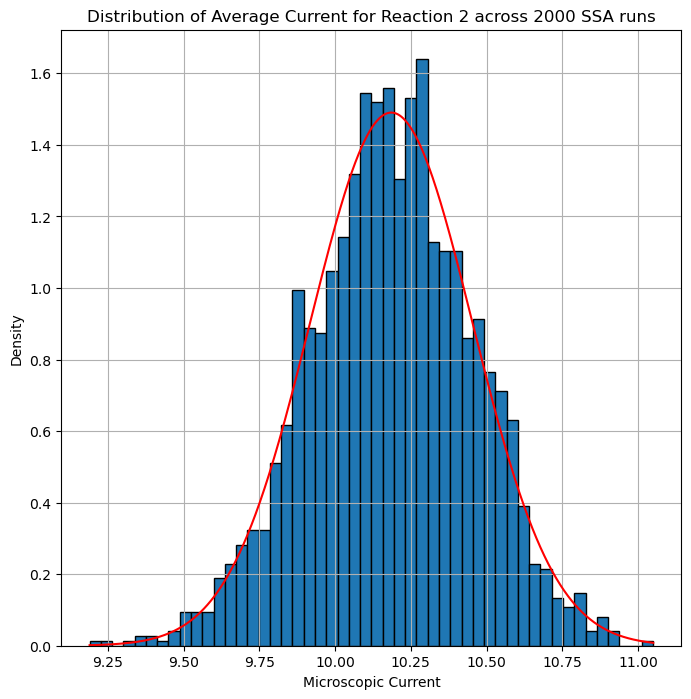

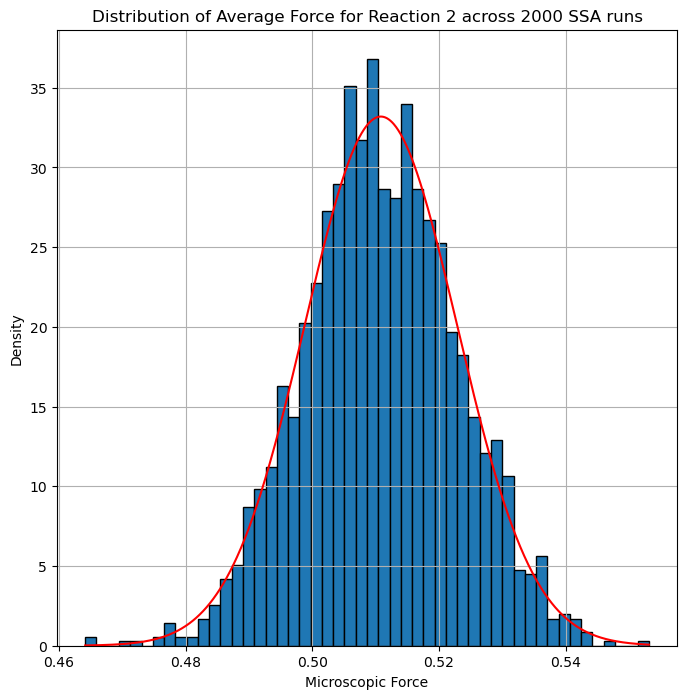

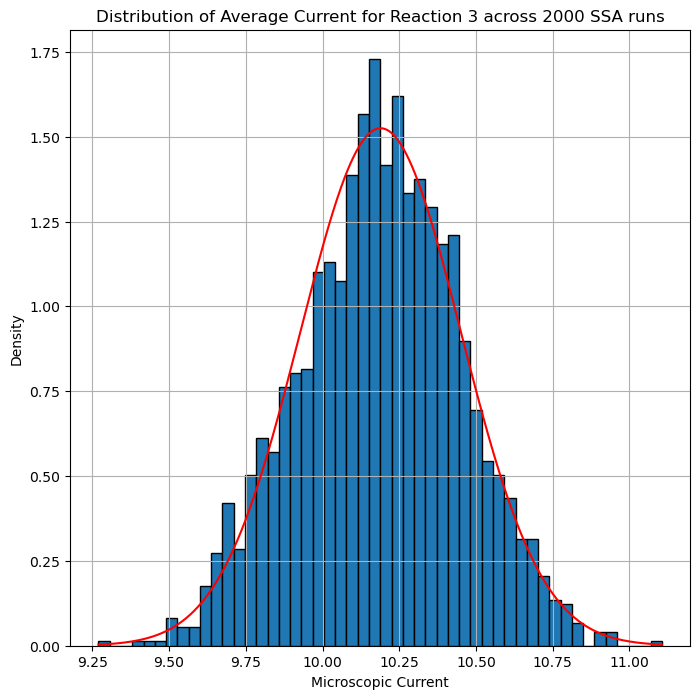

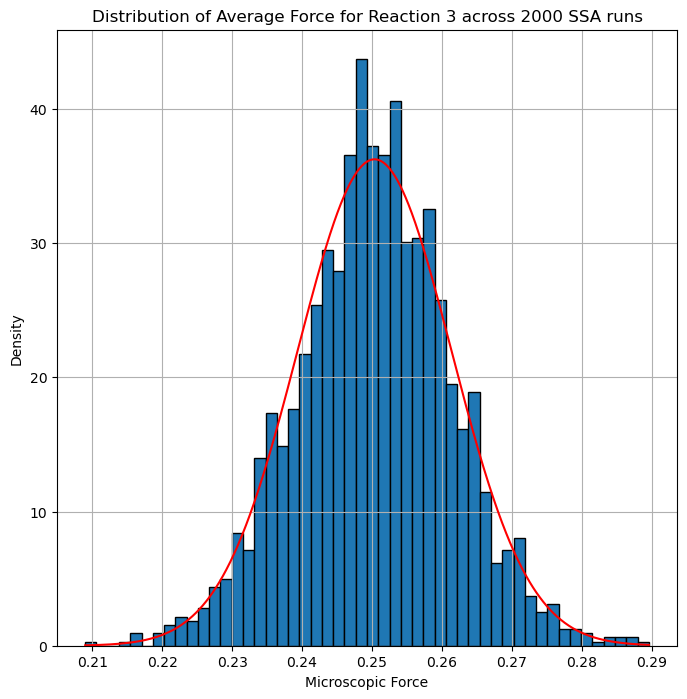

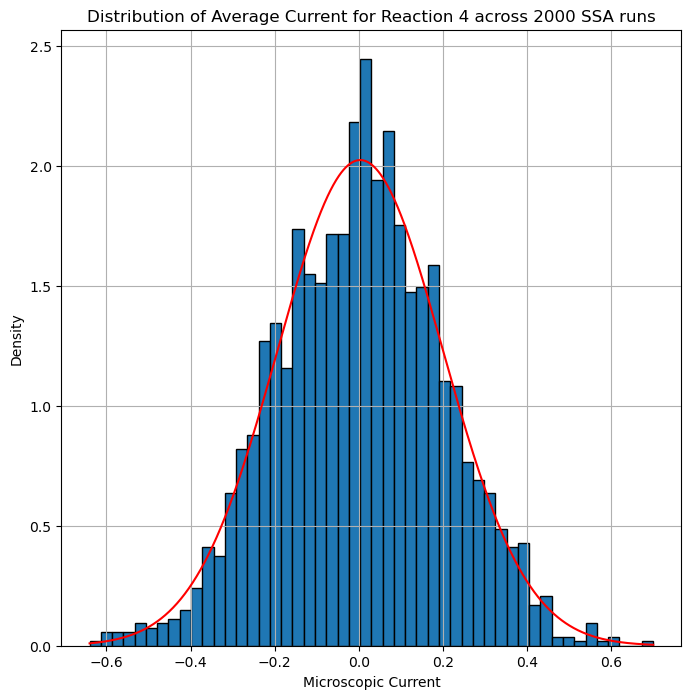

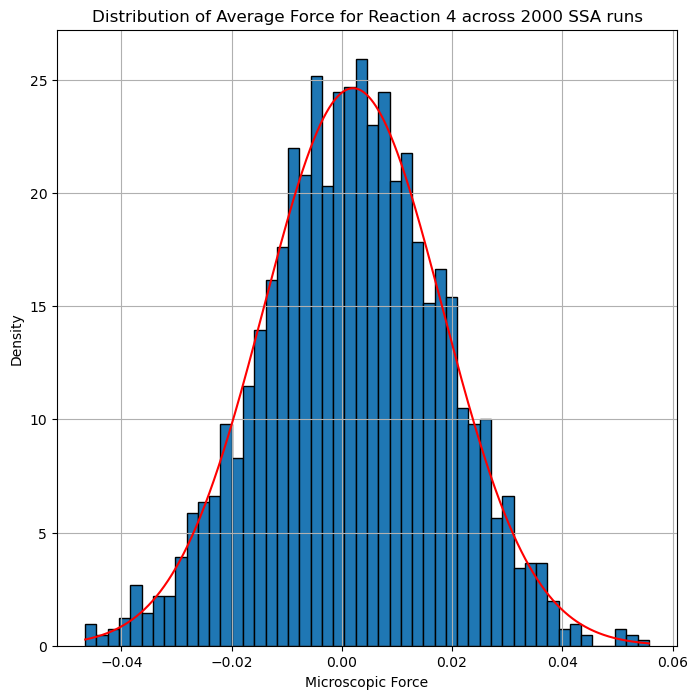

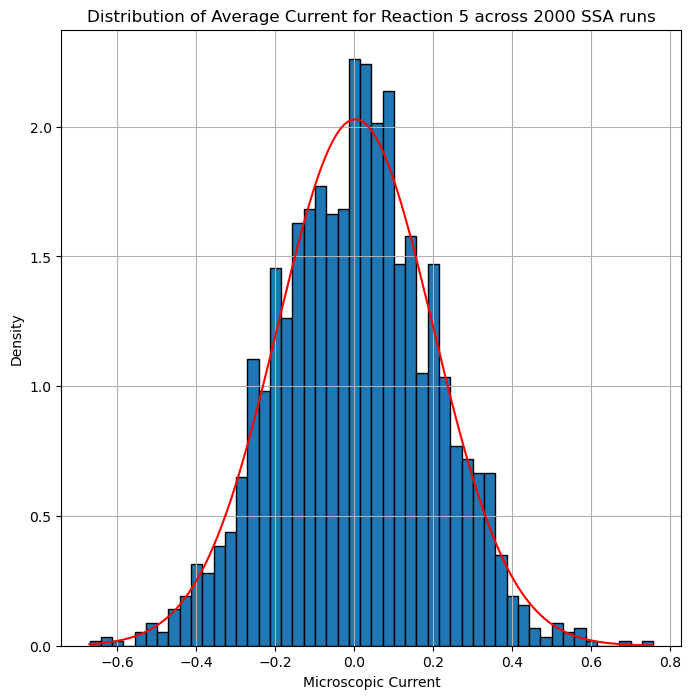

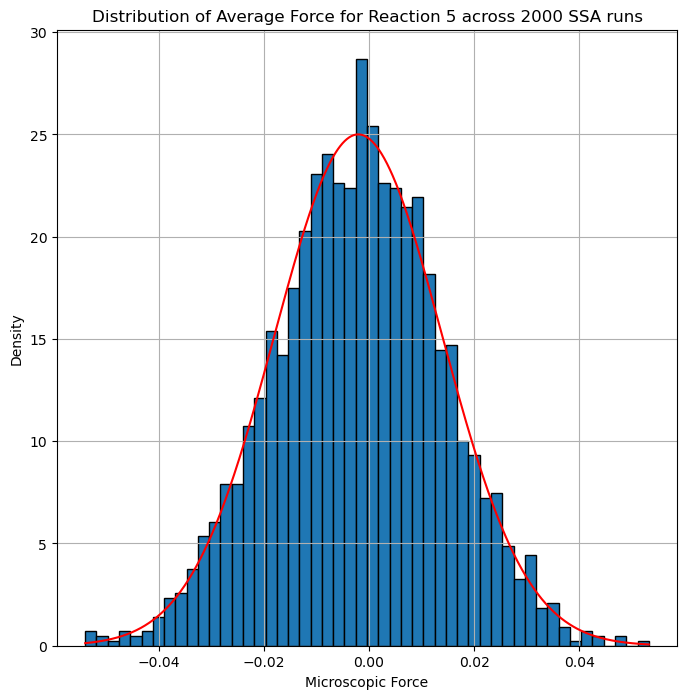

In [10]:
SIM2.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)

# Create I-F curves for the reactions in the module for a varied initial species count

## Compute I-F data from simulation

In [7]:
# Run SSA sweeps over a varying initial count. In this line, we vary the species at position 3 in species_names ('S') with integer 
# values between 50 and 500, running 40 iterations for each value of 'S'. We opt for 'verbose=True' so that we might track the progress
# through the various 'S' values. The 'covariance_reaction_indicies' tells the code which currents to sample the covariance between,
# this should be the set of currents in the fundamental current vector. For module 1, I = j1, so we set this = [0]. For module 2,
# I_ = (j3, j5) so we choose = [2, 4].

# Module 1

SIM1.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=400, 
        covariance_reaction_indices=[0],   
        verbose=True)


Sweep 1/50  (Varying Species: [S] = 50)
Sweep 2/50  (Varying Species: [S] = 59)
Sweep 3/50  (Varying Species: [S] = 68)
Sweep 4/50  (Varying Species: [S] = 77)
Sweep 5/50  (Varying Species: [S] = 86)
Sweep 6/50  (Varying Species: [S] = 95)
Sweep 7/50  (Varying Species: [S] = 105)
Sweep 8/50  (Varying Species: [S] = 114)
Sweep 9/50  (Varying Species: [S] = 123)
Sweep 10/50  (Varying Species: [S] = 132)
Sweep 11/50  (Varying Species: [S] = 141)
Sweep 12/50  (Varying Species: [S] = 151)
Sweep 13/50  (Varying Species: [S] = 160)
Sweep 14/50  (Varying Species: [S] = 169)
Sweep 15/50  (Varying Species: [S] = 178)
Sweep 16/50  (Varying Species: [S] = 187)
Sweep 17/50  (Varying Species: [S] = 196)
Sweep 18/50  (Varying Species: [S] = 206)
Sweep 19/50  (Varying Species: [S] = 215)
Sweep 20/50  (Varying Species: [S] = 224)
Sweep 21/50  (Varying Species: [S] = 233)
Sweep 22/50  (Varying Species: [S] = 242)
Sweep 23/50  (Varying Species: [S] = 252)
Sweep 24/50  (Varying Species: [S] = 261)
Sweep 2

SystemError: CPUDispatcher(<function ssa_core at 0x10f944360>) returned a result with an exception set

In [ ]:
# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=250, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/50  (species[Na] = 50)
Sweep 2/50  (species[Na] = 59)
Sweep 3/50  (species[Na] = 68)
Sweep 4/50  (species[Na] = 77)
Sweep 5/50  (species[Na] = 86)
Sweep 6/50  (species[Na] = 95)
Sweep 7/50  (species[Na] = 105)
Sweep 8/50  (species[Na] = 114)
Sweep 9/50  (species[Na] = 123)
Sweep 10/50  (species[Na] = 132)
Sweep 11/50  (species[Na] = 141)
Sweep 12/50  (species[Na] = 151)
Sweep 13/50  (species[Na] = 160)
Sweep 14/50  (species[Na] = 169)
Sweep 15/50  (species[Na] = 178)
Sweep 16/50  (species[Na] = 187)
Sweep 17/50  (species[Na] = 196)
Sweep 18/50  (species[Na] = 206)
Sweep 19/50  (species[Na] = 215)
Sweep 20/50  (species[Na] = 224)
Sweep 21/50  (species[Na] = 233)
Sweep 22/50  (species[Na] = 242)
Sweep 23/50  (species[Na] = 252)
Sweep 24/50  (species[Na] = 261)
Sweep 25/50  (species[Na] = 270)
Sweep 26/50  (species[Na] = 279)
Sweep 27/50  (species[Na] = 288)
Sweep 28/50  (species[Na] = 297)
Sweep 29/50  (species[Na] = 307)
Sweep 30/50  (species[Na] = 316)
Sweep 31/50  (species[Na]

## Plot the curves

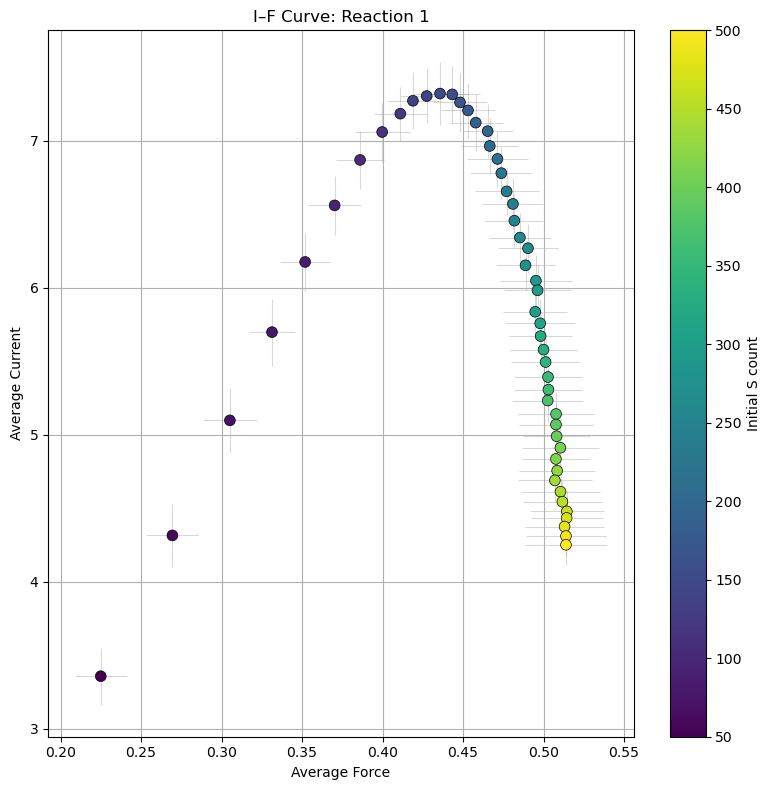

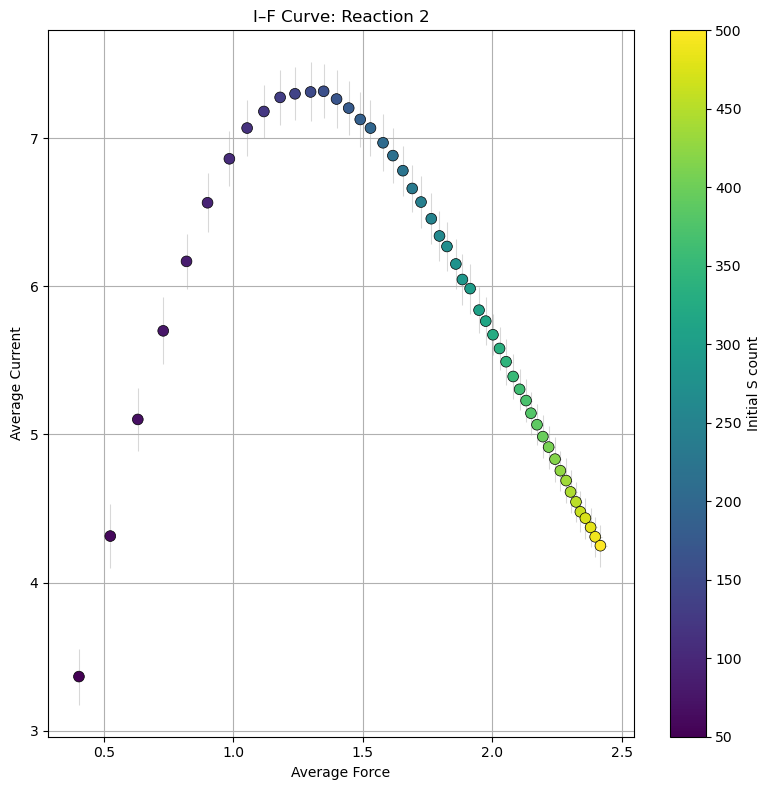

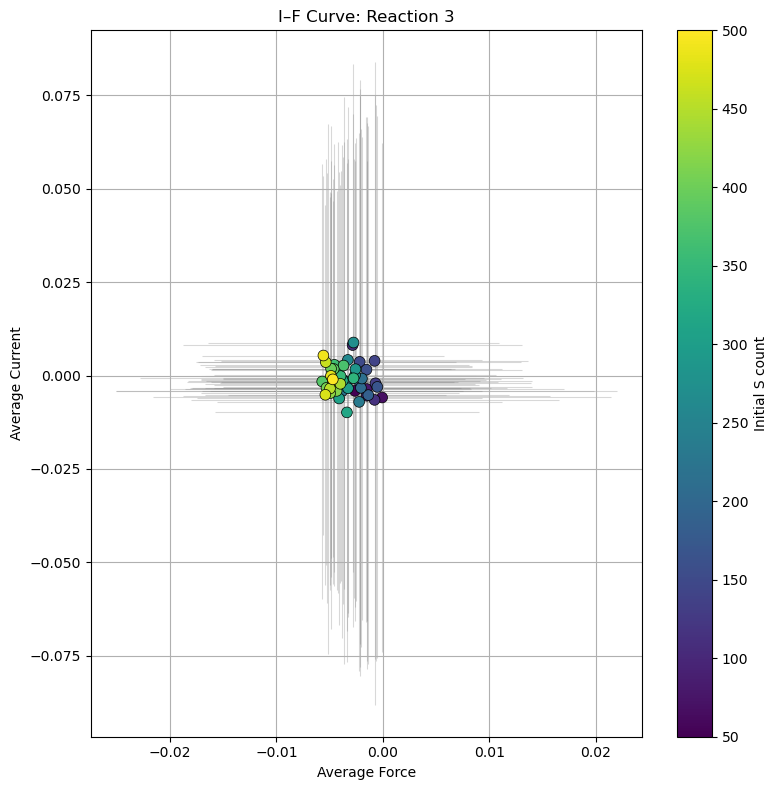

In [ ]:
# Now, we can plot the resulting I-F curves. We can select which to plot with 'reaction_indices', note that 'reaction 1' has index 0.
# Default is to plot all reactions. We can opt to plot any analytical results we may have calculated by passing these as lists into
# 'analytical_currents' and 'analytical_forces'.

# Module 1

SIM1.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

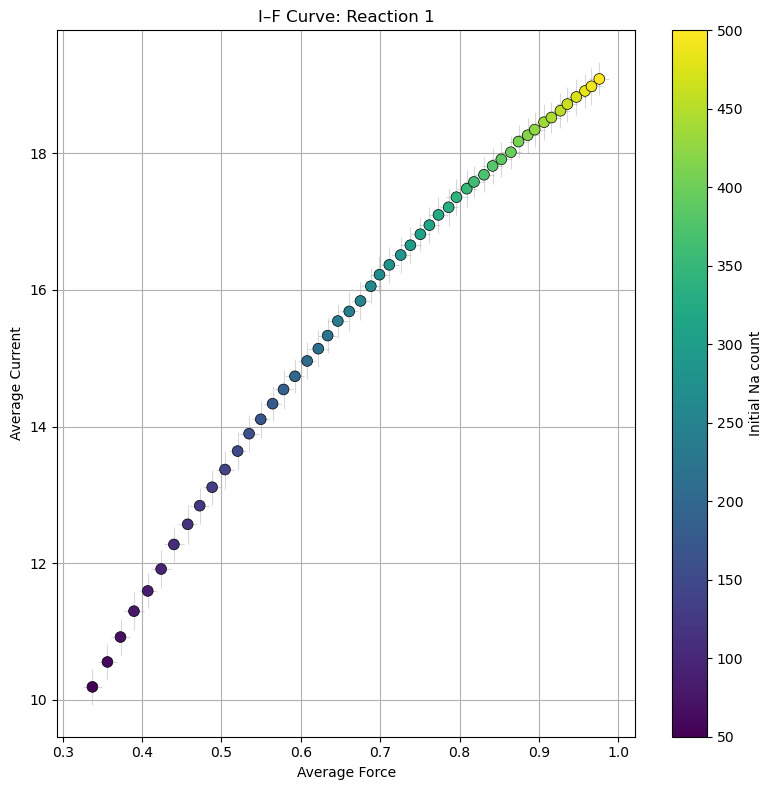

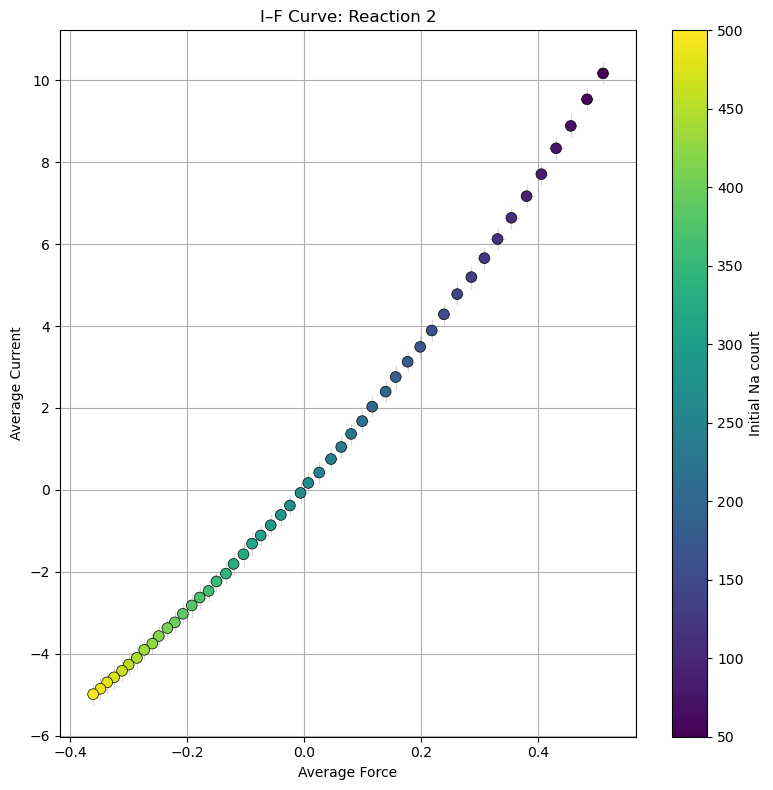

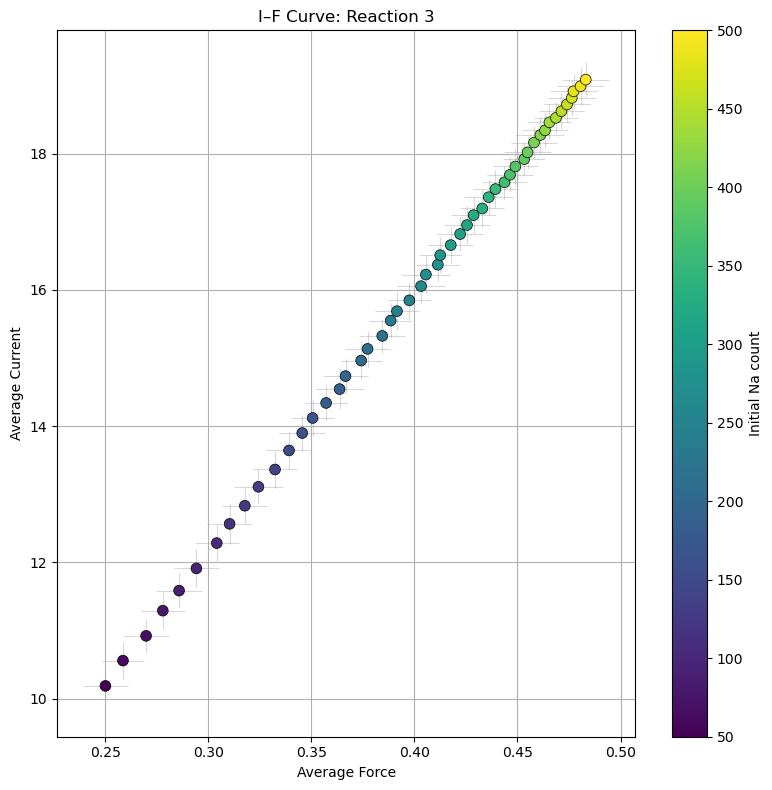

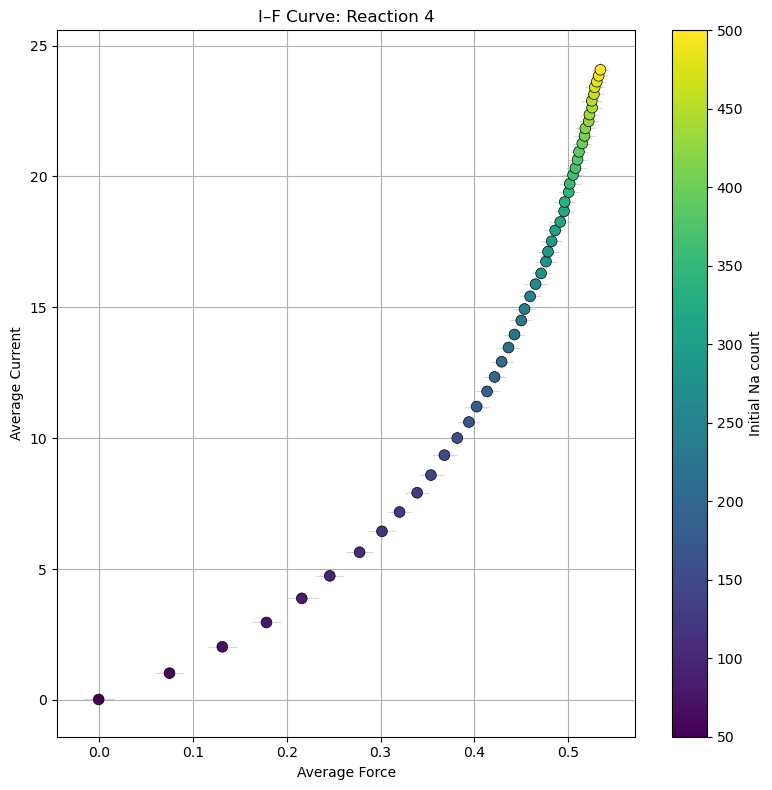

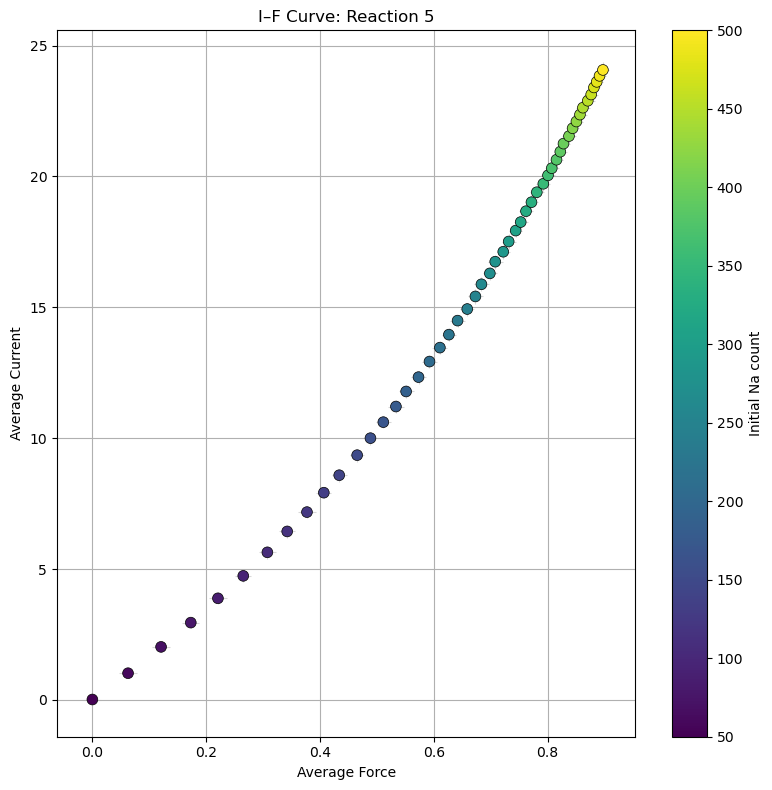

In [ ]:
# Module 2

SIM2.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

In [ ]:
# Calculate conductance of our individual CRNs. Again, we can opt to plot any analytical results for the conductance by passing the 
# currents and forces as lists into 'analytical_currents' and 'analytical_forces'.

SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

In [ ]:
SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

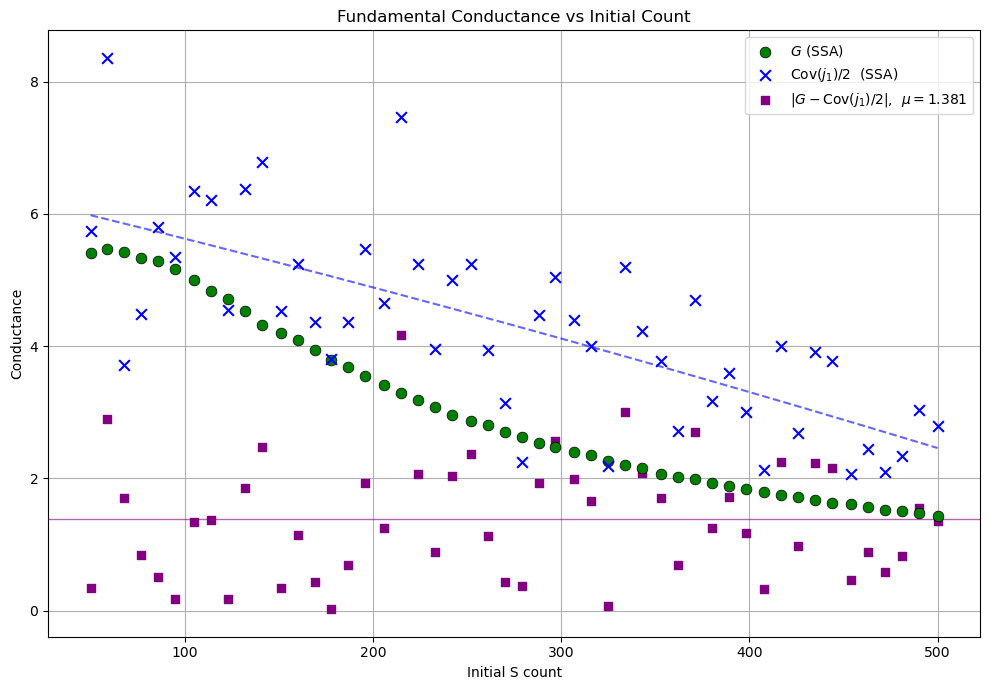

In [ ]:
# Plot the conductances. For module 1, we expect a scalar value, so the code will plot this scalar conductance vs the count values.
# We can opt to plot the covariance of the currents and forces with 'show_covariance=True', this plots Cov(I)/2. Also, we can plot
# the difference between the numerical and analytical conductances with 'show_difference=True', this plots the value |G - Cov(I)/2|. 
# We can also fit a polynomial of order 'fit_order' to the numerical conductance values.

# Module 1

SIM1.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )

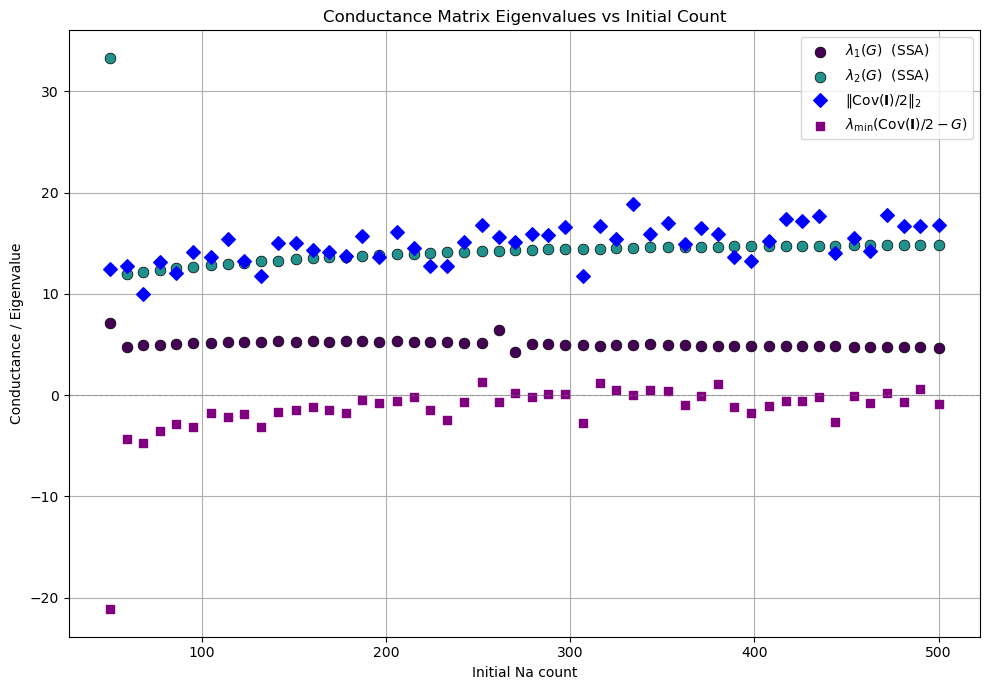

In [ ]:
# Module 2

SIM2.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )